In [62]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
%matplotlib inline

In [18]:
counties = gpd.read_file('../../geospatial-BigECire/data/county/tncounty.shp')
counties.head()

,OBJECTID,NAME,KEY,SHAPE_AREA,SHAPE_LEN,geometry
0,76,Chester,47023,8.049024e+09,520461.080124,"POLYGON ((1137985.762 344601.643, 1137965.070 ..."
1,77,Wayne,47181,2.050741e+10,666520.678598,"POLYGON ((1365052.057 391716.806, 1365746.554 ..."
2,78,Tipton,47167,1.319125e+10,865093.887634,"MULTIPOLYGON (((886814.330 400456.525, 886774...."
3,79,Hamilton,47065,1.604776e+10,652926.001078,"POLYGON ((2274954.438 239788.911, 2274090.610 ..."
4,80,Stewart,47161,1.375003e+10,490090.336180,"POLYGON ((1382472.783 743972.302, 1382445.171 ..."


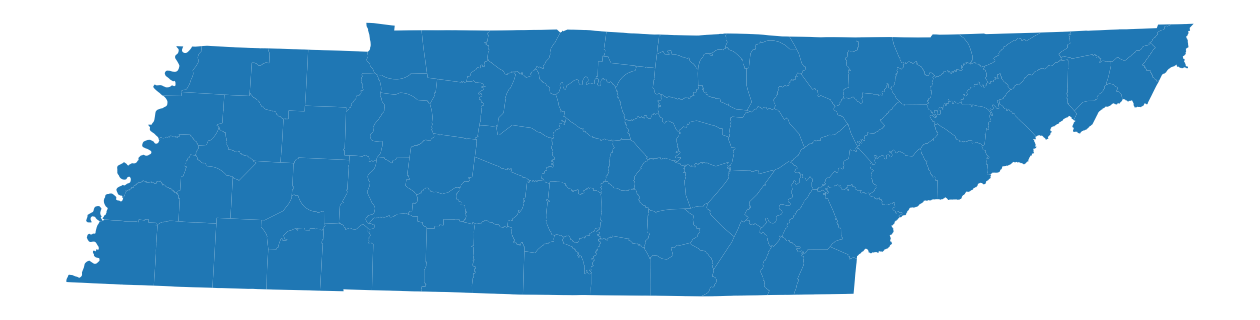

In [19]:
fig, ax = plt.subplots(figsize=(16,4))
counties.plot(ax = ax)
ax.axis('off');

In [20]:
slopes = pd.read_csv('../data/slopes.csv')
slopes.head()

,county,total_deaths
0,ANDERSON,0.4
1,BEDFORD,-0.1
2,BENTON,-0.5
3,BLEDSOE,0.6
4,BLOUNT,4.1


In [21]:
counties.NAME = counties.NAME.str.upper().replace({'DEKALB': 'DE KALB', 'MCMINN': 'MC MINN', 'MCNAIRY': 'MC NAIRY'})
counties = pd.merge(left = counties, right = slopes, 
                    left_on = 'NAME', right_on = 'county')
counties.head()

,OBJECTID,NAME,KEY,SHAPE_AREA,SHAPE_LEN,geometry,county,total_deaths
0,76,CHESTER,47023,8.049024e+09,520461.080124,"POLYGON ((1137985.762 344601.643, 1137965.070 ...",CHESTER,-0.7
1,77,WAYNE,47181,2.050741e+10,666520.678598,"POLYGON ((1365052.057 391716.806, 1365746.554 ...",WAYNE,0.2
2,78,TIPTON,47167,1.319125e+10,865093.887634,"MULTIPOLYGON (((886814.330 400456.525, 886774....",TIPTON,-0.4
3,79,HAMILTON,47065,1.604776e+10,652926.001078,"POLYGON ((2274954.438 239788.911, 2274090.610 ...",HAMILTON,1.9
4,80,STEWART,47161,1.375003e+10,490090.336180,"POLYGON ((1382472.783 743972.302, 1382445.171 ...",STEWART,1.4


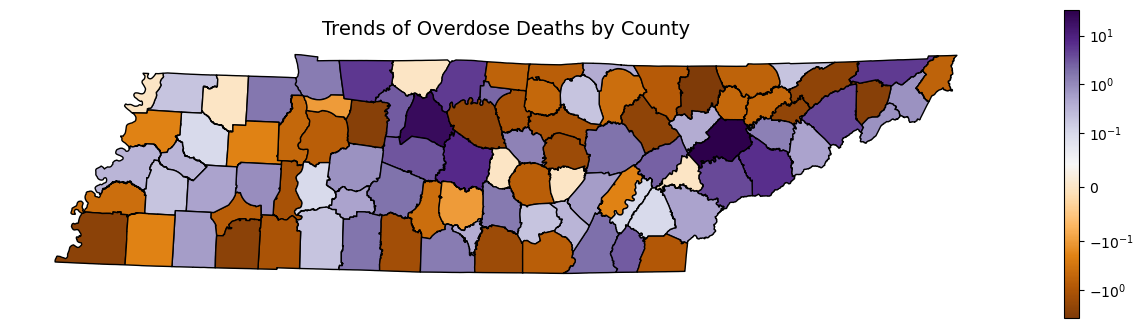

In [123]:
fig, ax = plt.subplots(figsize=(16,4))
norm = mcolors.SymLogNorm(linthresh=0.1, vmin=slopes.total_deaths.min(), vmax=slopes.total_deaths.max())
counties.plot(column = 'total_deaths', 
              cmap = 'PuOr', 
              norm=norm,
              edgecolor = 'black', 
              legend = True,
              ax = ax)
plt.title('Trends of Overdose Deaths by County', fontsize = 14)
ax.axis('off');
plt.savefig("DeathsbyCounty.png", dpi=300, bbox_inches='tight')

In [23]:
slopes.total_deaths.max()

33.69999999999997

In [24]:
slopes.total_deaths.min()

-3.800000000000004

In [55]:
q4a = pd.read_csv('../data/q4a.csv')
q4a

,Unnamed: 0,county,year,unemployment_rate,overdose_deaths
0,0,ANDERSON,2015,5.825000,20
1,1,ANDERSON,2016,4.850000,24
2,2,ANDERSON,2017,3.950000,34
3,3,ANDERSON,2018,3.750000,18
4,4,BEDFORD,2015,6.433333,8
...,...,...,...,...,...
375,375,WILLIAMSON,2018,2.625000,30
376,376,WILSON,2015,7.875000,26
377,377,WILSON,2016,6.858333,27
378,378,WILSON,2017,5.250000,26


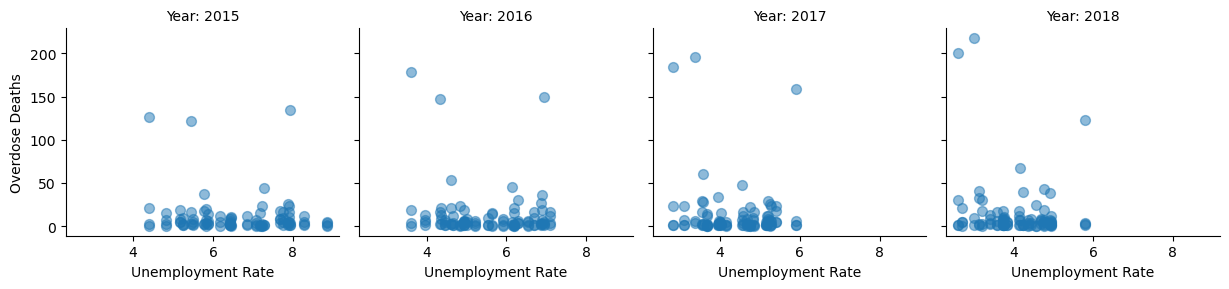

In [104]:
g = sns.FacetGrid(q4a, col='year', col_wrap=10)
g.map(plt.scatter, 'unemployment_rate', 'overdose_deaths', s=50, alpha=.5)
g.set_titles(col_template="Year: {col_name}")
g.set_xlabels(label='Unemployment Rate')
g.set_ylabels(label='Overdose Deaths')

In [68]:
q4a.sort_values(by='overdose_deaths', ascending=False).head(15)

,Unnamed: 0,county,year,unemployment_rate,overdose_deaths
187,187,KNOX,2018,3.008333,218
75,75,DAVIDSON,2018,2.625000,200
186,186,KNOX,2017,3.375000,196
74,74,DAVIDSON,2017,2.816667,184
73,73,DAVIDSON,2016,3.600000,178
314,314,SHELBY,2017,5.908333,159
313,313,SHELBY,2016,6.941667,150
185,185,KNOX,2016,4.333333,147
312,312,SHELBY,2015,7.933333,135
72,72,DAVIDSON,2015,4.391667,127


In [105]:
pop = pd.read_csv('../data/population.csv')
pop

,county,population
0,ANDERSON,75538
1,BEDFORD,46854
2,BENTON,16154
3,BLEDSOE,14413
4,BLOUNT,127135
...,...,...
90,WAYNE,16713
91,WEAKLEY,33776
92,WHITE,26394
93,WILLIAMSON,212161


In [106]:
q4a_pop = pd.merge(q4a, pop, 
                               left_on = 'county', right_on = 'county', 
                               how = 'inner')
q4a_pop.head()

,Unnamed: 0,county,year,unemployment_rate,overdose_deaths,population
0,0,ANDERSON,2015,5.825000,20,75538
1,1,ANDERSON,2016,4.850000,24,75538
2,2,ANDERSON,2017,3.950000,34,75538
3,3,ANDERSON,2018,3.750000,18,75538
4,4,BEDFORD,2015,6.433333,8,46854


In [108]:
q4a_pop['norm_overdose_deaths'] = q4a_pop.overdose_deaths / q4a_pop.population
q4a_pop.head()

,Unnamed: 0,county,year,unemployment_rate,overdose_deaths,population,norm_overdose_deaths
0,0,ANDERSON,2015,5.825000,20,75538,0.000265
1,1,ANDERSON,2016,4.850000,24,75538,0.000318
2,2,ANDERSON,2017,3.950000,34,75538,0.000450
3,3,ANDERSON,2018,3.750000,18,75538,0.000238
4,4,BEDFORD,2015,6.433333,8,46854,0.000171


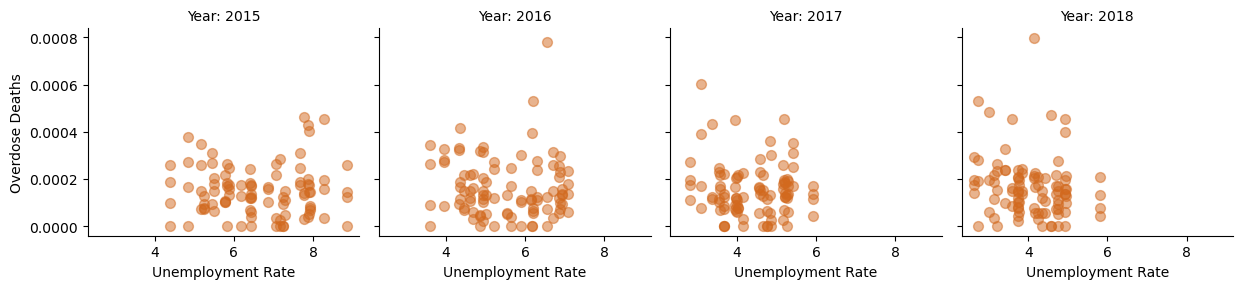

In [122]:
g = sns.FacetGrid(q4a_pop, col='year', col_wrap=10)
g.map(plt.scatter, 'unemployment_rate', 'norm_overdose_deaths', color='chocolate', s=50, alpha=.5)
g.set_titles(col_template="Year: {col_name}")
g.set_xlabels(label='Unemployment Rate')
g.set_ylabels(label='Overdose Deaths')
plt.savefig("DeathvsUnemployment.png", dpi=300, bbox_inches='tight')

In [69]:
q4a_cut = q4a[~q4a.county.isin(['DAVIDSON', 'KNOX', 'SHELBY'])]

In [70]:
q4a_cut.sort_values(by='overdose_deaths', ascending=False).head(15)

,Unnamed: 0,county,year,unemployment_rate,overdose_deaths
299,299,RUTHERFORD,2018,4.166667,68
130,130,HAMILTON,2017,3.566667,60
129,129,HAMILTON,2016,4.608333,53
298,298,RUTHERFORD,2017,4.558333,48
297,297,RUTHERFORD,2016,6.141667,45
296,296,RUTHERFORD,2015,7.283333,44
327,327,SULLIVAN,2018,4.758333,43
131,131,HAMILTON,2018,3.141667,41
251,251,MONTGOMERY,2018,4.241667,40
311,311,SEVIER,2018,4.925000,38


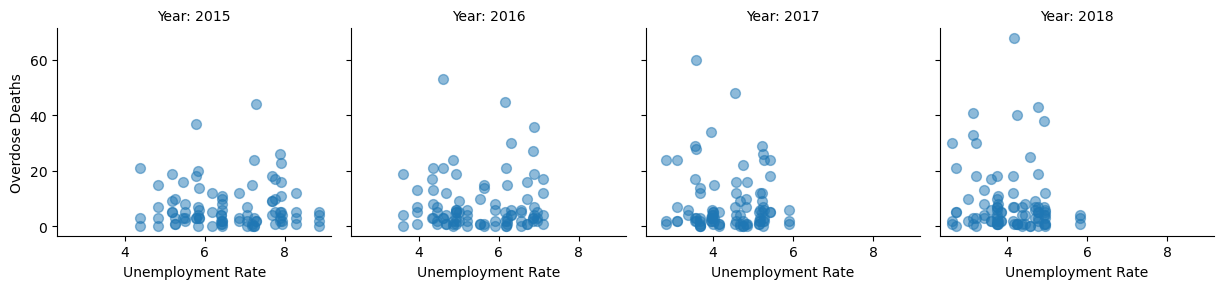

In [103]:
g = sns.FacetGrid(q4a_cut, col='year', col_wrap=10)
g.map(plt.scatter, 'unemployment_rate', 'overdose_deaths', s=50, alpha=.5)
g.set_titles(col_template="Year: {col_name}")
g.set_xlabels(label='Unemployment Rate')
g.set_ylabels(label='Overdose Deaths')

In [77]:
q4a_cut[~q4a_cut.year.isin([2018])].corr(numeric_only = True)

,Unnamed: 0,year,unemployment_rate,overdose_deaths
Unnamed: 0,1.000000,0.007419,-0.035518,0.108856
year,0.007419,1.000000,-0.678874,0.036917
unemployment_rate,-0.035518,-0.678874,1.000000,-0.033297
overdose_deaths,0.108856,0.036917,-0.033297,1.000000


In [81]:
q4b = pd.read_csv('../data/q4b.csv').reset_index(drop=True).drop(columns = 'Unnamed: 0')
q4b

,county,unemployment_rate,total_opioid_cost
0,ANDERSON,5.866667,1805218.80
1,BEDFORD,6.403333,1837046.71
2,BENTON,7.743333,705983.39
3,BLEDSOE,8.050000,863960.83
4,BLOUNT,5.203333,1393867.73
...,...,...,...
90,WAYNE,5.610000,786064.46
91,WEAKLEY,6.506667,3294437.90
92,WHITE,6.980000,420266.35
93,WILLIAMSON,4.353333,4527570.95


''

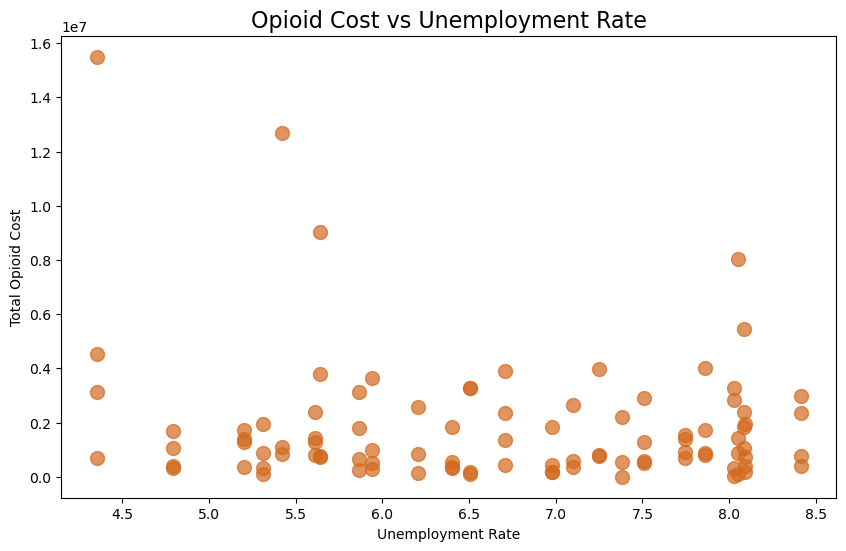

In [116]:
q4b.plot(kind = 'scatter',
             x = 'unemployment_rate',
             y = 'total_opioid_cost',
             figsize = (10,6), 
             color='chocolate', 
             s=100, 
             alpha=.7)
plt.ylabel('Total Opioid Cost')
plt.xlabel('Unemployment Rate')
plt.title('Opioid Cost vs Unemployment Rate', fontsize = 16)
;

In [117]:
q4b_pop = pd.merge(q4b, pop, 
                               left_on = 'county', right_on = 'county', 
                               how = 'inner')
q4b_pop.head()

,county,unemployment_rate,total_opioid_cost,population
0,ANDERSON,5.866667,1805218.80,75538
1,BEDFORD,6.403333,1837046.71,46854
2,BENTON,7.743333,705983.39,16154
3,BLEDSOE,8.050000,863960.83,14413
4,BLOUNT,5.203333,1393867.73,127135


In [119]:
q4b_pop['norm_total_opioid_cost'] = q4b_pop.total_opioid_cost / q4b_pop.population
q4b_pop.head()

,county,unemployment_rate,total_opioid_cost,population,norm_total_opioid_cost
0,ANDERSON,5.866667,1805218.80,75538,23.898155
1,BEDFORD,6.403333,1837046.71,46854,39.207895
2,BENTON,7.743333,705983.39,16154,43.703317
3,BLEDSOE,8.050000,863960.83,14413,59.943165
4,BLOUNT,5.203333,1393867.73,127135,10.963682


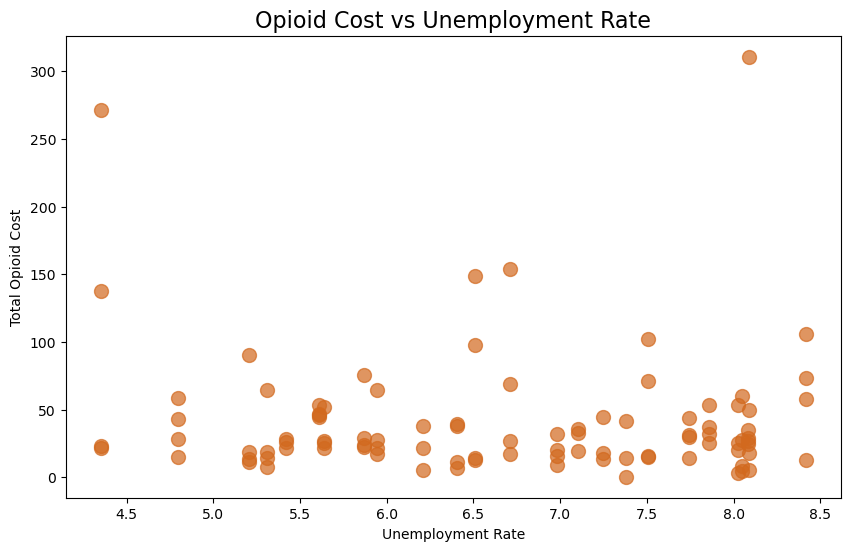

In [121]:
q4b_pop.plot(kind = 'scatter',
             x = 'unemployment_rate',
             y = 'norm_total_opioid_cost',
             figsize = (10,6), 
             color='chocolate', 
             s=100, 
             alpha=.7)
plt.ylabel('Total Opioid Cost')
plt.xlabel('Unemployment Rate')
plt.title('Opioid Cost vs Unemployment Rate', fontsize = 16)
;
plt.savefig("CostvsUnemployment.png", dpi=300, bbox_inches='tight')